# Examen Parte 1: Github - Data
Parte 1: Integración de Datos en la Nube y Dashboard Interactivo de los Premios Nobel

1. Un conjunto de datos que incluye la información biográfica y general de los ganadores. Este
conjunto de datos se obtendrá de la siguiente dirección URL:
https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_personal.csv
2. Un conjunto de datos que proporciona los detalles específicos de cada galardón, categorías y
motivaciones oficiales. La dirección URL de este conjunto de datos es:
https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_data.csv

Tu tarea en esta fase consiste en:
1. Realizar el Join: Utilizando Python (Google Colab), carga ambos datasets mediante las fuentes
públicas correspondientes, realiza un cruce (join) adecuado utilizando las llaves de 'Firstname' y
'Lastname' para unificar la información en una sola tabla consolidada.
2. Exportar y Publicar: Guarda el resultado como un único archivo limpio en formato CSV y súbelo
a un repositorio público en tu cuenta de GitHub.
3. Obtener la URL Raw: Genera y copia el enlace directo RAW de tu archivo en GitHub, el cual se
utilizará como fuente de datos en vivo.

## Importacion y instalccion de librerias

In [4]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.7 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as plt
import streamlit as st
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

## Cargar CSV

In [35]:
url = 'https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_personal.csv'
df1 = pd.read_csv(url)
url2= "https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_data.csv"
df2 = pd.read_csv(url2)


In [36]:
df1.head()

,Laureate_Id,Firstname,Lastname,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country
0,1,Wilhelm Conrad,Röntgen,male,1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany
1,293,Emil,von Behring,male,1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany
2,462,Henry,Dunant,male,1828-05-08,Switzerland,Geneva,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN
3,463,Frédéric,Passy,male,1822-05-20,France,Paris,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN
4,569,Sully,Prudhomme,male,1839-03-16,France,Paris,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN


In [37]:
df2.head()

,Year,Laureate_Id,Firstname,Lastname,Category,Prize_Share,Motivation
0,1901,1,Wilhelm Conrad,Röntgen,physics,1,"""in recognition of the extraordinary services ..."
1,1901,293,Emil,von Behring,medicine,1,"""for his work on serum therapy especially its ..."
2,1901,462,Henry,Dunant,peace,2,"""for his humanitarian efforts to help wounded ..."
3,1901,463,Frédéric,Passy,peace,2,"""for his lifelong work for international peace..."
4,1901,569,Sully,Prudhomme,literature,1,"""in special recognition of his poetic composit..."


In [38]:
df2['Category'].unique()

array(['physics', 'medicine', 'peace', 'literature', 'chemistry',
       'economics'], dtype=object)

## JOIN entre los 2 conjunto de datos

In [74]:
dfcompleto = pd.merge(df1, df2, on=['Firstname', 'Lastname'])
dfcompleto.head()

,Laureate_Id_x,Firstname,Lastname,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Year,Laureate_Id_y,Category,Prize_Share,Motivation
0,1,Wilhelm Conrad,Röntgen,male,1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany,1901,1,physics,1,"""in recognition of the extraordinary services ..."
1,293,Emil,von Behring,male,1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany,1901,293,medicine,1,"""for his work on serum therapy especially its ..."
2,462,Henry,Dunant,male,1828-05-08,Switzerland,Geneva,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN,1901,462,peace,2,"""for his humanitarian efforts to help wounded ..."
3,463,Frédéric,Passy,male,1822-05-20,France,Paris,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN,1901,463,peace,2,"""for his lifelong work for international peace..."
4,569,Sully,Prudhomme,male,1839-03-16,France,Paris,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN,1901,569,literature,1,"""in special recognition of his poetic composit..."


## Archivo .py para extraer y juntar (download and join) csv

In [182]:
%%writefile extraeryjuntarDatos.py
import pandas as pd

script_code = """
import requests
import pandas as pd

# Descarga archivos en linea
url = 'https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_personal.csv'
df1 = pd.read_csv(url)
url2= "https://raw.githubusercontent.com/anaepm/rep/refs/heads/main/nobel_data.csv"
df2 = pd.read_csv(url2)

# JOIN entre los 2 conjunto de datos
dfcompleto = pd.merge(df1, df2, on=['Firstname', 'Lastname'])
dfcompleto.head()

#Convertir a DataFrame
df = pd.DataFrame(datos)
df.to_csv("PremiosNOVEL.csv", index=False)
print("archivo PremiosNOVEL.csv creado.")
"""

Writing extraeryjuntarDatos.py


## Exportar csv completo

In [75]:
filas,columnas=dfcompleto.shape
print(f"Dataset completo tiene columnas:{columnas} y filas:{filas} \n")

Dataset completo tiene columnas:20 y filas:1007 



In [77]:
dfcompleto.to_csv('nobel.csv', index=False)

## Link github dataset
`https://raw.githubusercontent.com/JoseColins1OO/ExamenModulo4/refs/heads/main/nobel%20(1).csv`

# Examen Parte 2: Preparacion de los datos


## Contexto
El registro histórico de los Premios Nobel resguarda la memoria de las contribuciones más
importantes de la humanidad. Cada galardón va acompañado de una motivación oficial —un breve
texto redactado por los comités académicos que describe con precisión el descubrimiento, avance o
impacto del ganador—.

La Fundación Nobel y los comités de análisis historiográfico están interesados en evaluar si la
terminología, el enfoque conceptual y el vocabulario técnico utilizados en estas descripciones
reflejan patrones tan distintivos que es posible automatizar su clasificación disciplinaria.

Como parte de tu colaboración, se te ha asignado el desarrollo de una herramienta interactiva que
permita predecir la categoría del Premio Nobel (por ejemplo: Física, Química, Medicina, Literatura,
Paz, etc.) a partir del texto de la motivación o de una descripción provista por el usuario.

## Leer conjunto de datos desde github


In [83]:
urlgit ="https://raw.githubusercontent.com/JoseColins1OO/ExamenModulo4/refs/heads/main/nobel%20(1).csv"
NovelDf = pd.read_csv(urlgit)
NovelDf


,Laureate_Id_x,Firstname,Lastname,Gender,Birth_Date,Birth_Country,Birth_City,Birth_Country_Code,Death_Date,Death_Country,Death_City,Death_Country_Code,Organization_Name,Organization_City,Organization_Country,Year,Laureate_Id_y,Category,Prize_Share,Motivation
0,1,Wilhelm Conrad,Röntgen,male,1845-03-27,Prussia (now Germany),Lennep (now Remscheid),DE,10/02/1923,Germany,Munich,DE,Munich University,Munich,Germany,1901,1,physics,1,"""in recognition of the extraordinary services ..."
1,293,Emil,von Behring,male,1854-03-15,Prussia (now Poland),Hansdorf (now Lawice),PL,31/03/1917,Germany,Marburg,DE,Marburg University,Marburg,Germany,1901,293,medicine,1,"""for his work on serum therapy especially its ..."
2,462,Henry,Dunant,male,1828-05-08,Switzerland,Geneva,CH,30/10/1910,Switzerland,Heiden,CH,NaN,NaN,NaN,1901,462,peace,2,"""for his humanitarian efforts to help wounded ..."
3,463,Frédéric,Passy,male,1822-05-20,France,Paris,FR,12/06/1912,France,Paris,FR,NaN,NaN,NaN,1901,463,peace,2,"""for his lifelong work for international peace..."
4,569,Sully,Prudhomme,male,1839-03-16,France,Paris,FR,07/09/1907,France,Châtenay,FR,NaN,NaN,NaN,1901,569,literature,1,"""in special recognition of his poetic composit..."
5,160,Jacobus H.,van 't Hoff,male,1852-08-30,the Netherlands,Rotterdam,NL,01/03/1911,Germany,Berlin,DE,Berlin University,Berlin,Germany,1901,160,chemistry,1,"""in recognition of the extraordinary services ..."
6,161,Emil,Fischer,male,1852-10-09,Prussia (now Germany),Euskirchen,DE,15/07/1919,Germany,Berlin,DE,Berlin University,Berlin,Germany,1902,161,chemistry,1,"""in recognition of the extraordinary services ..."
7,571,Theodor,Mommsen,male,1817-11-30,Schleswig (now Germany),Garding,DE,01/11/1903,Germany,Charlottenburg,DE,NaN,NaN,NaN,1902,571,literature,1,"""the greatest living master of the art of hist..."
8,465,Albert,Gobat,male,1843-05-21,Switzerland,Tramelan,CH,16/03/1914,Switzerland,Bern,CH,NaN,NaN,NaN,1902,465,peace,2,"""for his eminently practical administration of..."
9,464,Élie,Ducommun,male,1833-02-19,Switzerland,Geneva,CH,07/12/1906,Switzerland,Bern,CH,NaN,NaN,NaN,1902,464,peace,2,"""for his untiring and skilful directorship of ..."


## Analisis de datos

In [85]:
# Forma DataSet
filas,columnas=NovelDf.shape
print(f"Dataset completo tiene columnas:{columnas} y filas:{filas} \n")


Dataset completo tiene columnas:20 y filas:1007 



In [86]:
# Tipo de datos del DataSet
informacion = NovelDf.info()
print(informacion ,"\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Laureate_Id_x         1007 non-null   int64 
 1   Firstname             1007 non-null   object
 2   Lastname              967 non-null    object
 3   Gender                1007 non-null   object
 4   Birth_Date            1007 non-null   object
 5   Birth_Country         968 non-null    object
 6   Birth_City            966 non-null    object
 7   Birth_Country_Code    968 non-null    object
 8   Death_Date            1007 non-null   object
 9   Death_Country         654 non-null    object
 10  Death_City            648 non-null    object
 11  Death_Country_Code    654 non-null    object
 12  Organization_Name     736 non-null    object
 13  Organization_City     731 non-null    object
 14  Organization_Country  733 non-null    object
 15  Year                  1007 non-null   

In [87]:
# Datos estadisticos del DataSet
NovelDf.describe()

,Laureate_Id_x,Year,Laureate_Id_y,Prize_Share
count,1007.000000,1007.000000,1007.000000,1007.000000
mean,500.705065,1972.859980,500.705065,2.020854
std,294.240498,34.324108,294.240498,0.947195
min,1.000000,1901.000000,1.000000,1.000000
25%,244.500000,1949.000000,244.500000,1.000000
50%,490.000000,1978.000000,490.000000,2.000000
75%,751.500000,2002.000000,751.500000,3.000000
max,1023.000000,2022.000000,1023.000000,4.000000


Si borro los nulos se elimina todos los literatura, mejor los deje

In [72]:
#duplicados
#NovelDf.duplicated().sum()

np.int64(12)

In [73]:
#Eliminar Duplicados
#NovelDf.drop_duplicates(inplace=True)
#NovelDf.duplicated().sum()

np.int64(0)

In [74]:
# Nulos
#NovelDf.isnull().sum()

,0
Laureate_Id_x,0
Firstname,0
Lastname,32
Gender,0
Birth_Date,0
Birth_Country,31
Birth_City,33
Birth_Country_Code,31
Death_Date,0
Death_Country,345


In [75]:
# total nulos
#NovelDf.isnull().sum().sum()

np.int64(1965)

In [76]:
# Eliminar Nulos
#NovelDf = NovelDf.dropna()
#NovelDf.isnull().sum().sum()

np.int64(0)

In [88]:
#NovelDf['Category'].unique()

In [78]:
pd.set_option('display.max_rows', None)
NovelDf['Birth_Country'].value_counts()

,count
Birth_Country,
USA,143
United Kingdom,57
Germany,47
France,27
Poland,19
Russia,14
Netherlands,13
Sweden,13
Austria,12


In [89]:
reemplazos_paises = {
    'USSR (now Belarus)': 'Belarus',
    'the Netherlands': 'Netherlands',
    'Germany (now Poland)': 'Poland',
    'Prussia (now Poland)': 'Poland',
    'Prussia (now Germany)': 'Germany',
    'Austria-Hungary (now Hungary)': 'Hungary',
    'Austria-Hungary (now Czech Republic)': 'Czech Republic',
    'Germany (now Russia)': 'Russia',
    'Russian Empire (now Finland)': 'Finland',
    'Austrian Empire (now Austria)': 'Austria',
    'Russian Empire (now Poland)': 'Poland',
    'Russian Empire (now Ukraine)': 'Ukraine',
    'Russian Empire (now Russia)': 'Russia',
    'Germany (now France)': 'France',
    'India (now Pakistan)': 'Pakistan',
    'Austria-Hungary (now Slovenia)': 'Slovenia',
    'Java Dutch East Indies (now Indonesia)': 'Indonesia',
    'Bavaria (now Germany)': 'Germany',
    'Russian Empire (now Latvia)': 'Latvia',
    'Hungary (now Slovakia)': 'Slovakia',
    'Faroe Islands (Denmark)': 'Faroe Islands',
    'Schleswig (now Germany)': 'Germany',
    'Prussia (now Russia)': 'Russia',
    'Hesse-Kassel (now Germany)': 'Germany',
    'Mecklenburg (now Germany)': 'Germany',
    'Austria-Hungary (now Austria)': 'Austria',
    'Württemberg (now Germany)': 'Germany',
    'Austria-Hungary (now Poland)': 'Poland',
    'Austria-Hungary (now Croatia)': 'Croatia',
    'Russian Empire (now Azerbaijan)': 'Azerbaijan',
    'USSR (now Russia)': 'Russia',
    'Austria-Hungary (now Bosnia and Herzegovina)': 'Bosnia and Herzegovina',
    'British West Indies (now Saint Lucia)': 'Saint Lucia',
    'Korea (now South Korea)': 'South Korea',
    'Czechoslovakia (now Czech Republic)': 'Czech Republic',
    'British Mandate of Palestine (now Israel)': 'Israel',
    'West Germany (now Germany)': 'Germany',
    'French Algeria (now Algeria)': 'Algeria',
    'Austrian Empire (now Czech Republic)': 'Czech Republic',
    'Gold Coast (now Ghana)': 'Ghana',
    'British India (now India)': 'India',
    'British Protectorate of Palestine (now Israel)': 'Israel',
    'Tuscany (now Italy)': 'Italy',
    'Austrian Empire (now Italy)': 'Italy',
    'East Friesland (now Germany)': 'Germany',
    'Austria-Hungary (now Ukraine)': 'Ukraine',
    'Bosnia (now Bosnia and Herzegovina)': 'Bosnia and Herzegovina',
    'Crete (now Greece)': 'Greece',
    'Ottoman Empire (now North Macedonia)': 'North Macedonia',
    'Ottoman Empire (now Turkey)': 'Turkey',
    'Southern Rhodesia (now Zimbabwe)': 'Zimbabwe',
    'Poland (now Ukraine)': 'Ukraine',
    'Russian Empire (now Lithuania)': 'Lithuania',
    'Poland (now Lithuania)': 'Lithuania',
    'Tibet (now China)': 'China',
    'Burma (now Myanmar)': 'Myanmar',
    'Poland (now Belarus)': 'Belarus',
    'Free City of Danzig (now Poland)': 'Poland',
    'German-occupied Poland (now Poland)': 'Poland',
    'British India (now Bangladesh)': 'Bangladesh',
    'Persia (now Iran)': 'Iran',
    'Russian Empire (now Belarus)':'Belarus',
    'Belgian Congo (now Democratic Republic of the Congo)': 'Democratic Republic of the Congo'
}
NovelDf['Birth_Country'] = NovelDf['Birth_Country'].replace(reemplazos_paises)
print(NovelDf['Birth_Country'].value_counts())

Birth_Country
USA                                 295
United Kingdom                       92
Germany                              84
France                               59
Poland                               31
Sweden                               30
Russia                               28
Japan                                28
Canada                               21
Italy                                20
Switzerland                          19
Netherlands                          19
Austria                              19
China                                12
Denmark                              12
Norway                               12
Scotland                             11
Australia                            10
Hungary                               9
India                                 9
South Africa                          9
Belgium                               9
Spain                                 7
Egypt                                 6
Czech Republic            

In [56]:
NovelDf['Death_Country'].value_counts()

,count
Death_Country,
USA,239
United Kingdom,79
Germany,59
France,55
Sweden,29
Switzerland,29
Russia,16
Italy,15
Japan,11


In [92]:
reemplazos_paises_muerte = {
 'West Germany (now Germany)': 'Germany',
 'East Germany (now Germany)': 'Germany',
 'Germany (now Poland)': 'Poland',
 'Yugoslavia (now Serbia)': 'Serbia',
 'Northern Rhodesia (now Zambia)': 'Zambia',
 'USSR (now Russia)': 'Russia',
 'the Netherlands': 'Netherlands',
 'Czechoslovakia (now Czech Republic)': 'Czech Republic'
 }
NovelDf['Death_Country'] = NovelDf['Death_Country'].replace(reemplazos_paises_muerte)
print(NovelDf['Death_Country'].value_counts())

Death_Country
USA                 239
United Kingdom       79
Germany              59
France               55
Sweden               29
Switzerland          29
Russia               16
Italy                15
Japan                11
Spain                10
Netherlands          10
Denmark              10
Norway                8
Belgium               7
Austria               6
Canada                6
South Africa          5
Scotland              5
Poland                5
Northern Ireland      4
Mexico                4
Argentina             4
Israel                4
India                 3
Ireland               3
Egypt                 2
Czech Republic        2
Greece                2
Finland               2
Australia             2
Romania               1
Portugal              1
Iceland               1
Puerto Rico           1
Jamaica               1
Gabon                 1
Tunisia               1
Serbia                1
Chile                 1
Zambia                1
Vietnam               1
Ba

In [93]:
reemplazos_pais_organizador= {
 'USSR (now Russia)': 'Russia',
 'Germany (now France)': 'France',
 'Czechoslovakia (now Czech Republic)': 'Czech Republic',
 'the Netherlands': 'Netherlands'
 }

In [94]:
NovelDf['Organization_Country'] = NovelDf['Organization_Country'].replace(reemplazos_pais_organizador)
print(NovelDf['Organization_Country'].value_counts())

Organization_Country
USA               385
United Kingdom     95
Germany            71
France             40
Switzerland        24
Sweden             17
Japan              17
Russia             12
Netherlands        10
Canada              9
Denmark             9
Austria             7
Italy               7
Norway              5
Belgium             5
Israel              5
Australia           4
Argentina           2
Spain               1
Finland             1
Hungary             1
India               1
Tunisia             1
Czech Republic      1
Ireland             1
Portugal            1
China               1
Name: count, dtype: int64


In [95]:
reemplazos_ciudad_nacido= {
 'Breslau (now Wroclaw)': 'Wroclaw',
 'Kristiania (now Oslo)': 'Oslo',
 'Koenigsberg (now Kaliningrad)	': 'Kaliningrad',
 'Strehlen (now Strzelin)': 'Strzelin',
 'Königshütte (now Chorzów)': 'Chorzów',
 'Goldschmieden near Breslau': 'Goldschmieden',
 'Laibach (now Ljubljana)': 'Ljubljana',
 'Sorau (now Zory)': 'Zory',
 'Priluka (now Nova Pryluka)': 'Pryluka',
 'Briesen (now Wąbrzeźno)':	'Wąbrzeźno',
 'Leningrad (now St. Petersburg)': 'St. Petersburg',
 'Neisse (now Nysa)': 'Nysa',
 'Clausthal (now Clausthal-Zellerfeld)':'Clausthal-Zellerfeld',
 'Gaffken (now Parusnoye)': 'Parusnoye',
 'Lennep (now Remscheid) ': 'Remscheid',
 'Koenigsberg (now Kaliningrad)':'Kaliningrad'
 }

In [96]:
NovelDf['Birth_City'] = NovelDf['Birth_City'].replace(reemplazos_ciudad_nacido)
print(NovelDf['Birth_City'].value_counts())

Birth_City
New York NY                         54
Paris                               26
London                              19
Vienna                              14
Chicago IL                          13
Berlin                              11
Boston MA                            9
Budapest                             8
Brooklyn NY                          8
Washington D.C.                      8
Munich                               7
Hamburg                              7
Moscow                               7
Stockholm                            7
Frankfurt-on-the-Main                6
Philadelphia PA                      6
Prague                               5
Warsaw                               5
Cairo                                4
Montreal                             4
Pittsburgh PA                        4
St. Petersburg                       4
Portland OR                          4
Rendcombe                            4
Copenhagen                           4
Madison WI    

In [97]:
NovelDf['Birth_City'].value_counts()

,count
Birth_City,
New York NY,54
Paris,26
London,19
Vienna,14
Chicago IL,13
Berlin,11
Boston MA,9
Budapest,8
Brooklyn NY,8


## Conjunto de datos para PowerBI


In [165]:
nombre_archivo = 'NovelLimpio.csv'
NovelDf.to_csv(nombre_archivo, index=False, encoding='utf-8')

#git link
git_link = 'https://raw.githubusercontent.com/JoseColins1OO/ExamenModulo4/refs/heads/main/NovelLimpio.csv'

In [123]:
df_nobel = NovelDf[['Category', 'Motivation']]
df_nobel

,Category,Motivation
0,physics,"""in recognition of the extraordinary services ..."
1,medicine,"""for his work on serum therapy especially its ..."
2,peace,"""for his humanitarian efforts to help wounded ..."
3,peace,"""for his lifelong work for international peace..."
4,literature,"""in special recognition of his poetic composit..."
5,chemistry,"""in recognition of the extraordinary services ..."
6,chemistry,"""in recognition of the extraordinary services ..."
7,literature,"""the greatest living master of the art of hist..."
8,peace,"""for his eminently practical administration of..."
9,peace,"""for his untiring and skilful directorship of ..."


In [124]:
df_nobel.describe()

,Category,Motivation
count,1007,1007
unique,6,684
top,physics,"""for promoting the principles of the Geneva Co..."
freq,225,4


In [125]:
df_nobel['Category'].unique()

array(['physics', 'medicine', 'peace', 'literature', 'chemistry',
       'economics'], dtype=object)

In [126]:
df_nobel['Etiqueta'] =  df_nobel.Category.map({'physics':0, 'medicine':1, 'peace':2, 'literature':3, 'chemistry':4, 'economics':5})
df_nobel

/tmp/ipykernel_406/347922274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nobel['Etiqueta'] =  df_nobel.Category.map({'physics':0, 'medicine':1, 'peace':2, 'literature':3, 'chemistry':4, 'economics':5})


,Category,Motivation,Etiqueta
0,physics,"""in recognition of the extraordinary services ...",0
1,medicine,"""for his work on serum therapy especially its ...",1
2,peace,"""for his humanitarian efforts to help wounded ...",2
3,peace,"""for his lifelong work for international peace...",2
4,literature,"""in special recognition of his poetic composit...",3
5,chemistry,"""in recognition of the extraordinary services ...",4
6,chemistry,"""in recognition of the extraordinary services ...",4
7,literature,"""the greatest living master of the art of hist...",3
8,peace,"""for his eminently practical administration of...",2
9,peace,"""for his untiring and skilful directorship of ...",2


In [127]:
df_nobel['len'] = df_nobel.Motivation.apply(len)
df_nobel

/tmp/ipykernel_406/14643857.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nobel['len'] = df_nobel.Motivation.apply(len)


,Category,Motivation,Etiqueta,len
0,physics,"""in recognition of the extraordinary services ...",0,131
1,medicine,"""for his work on serum therapy especially its ...",1,240
2,peace,"""for his humanitarian efforts to help wounded ...",2,94
3,peace,"""for his lifelong work for international peace...",2,85
4,literature,"""in special recognition of his poetic composit...",3,177
5,chemistry,"""in recognition of the extraordinary services ...",4,146
6,chemistry,"""in recognition of the extraordinary services ...",4,104
7,literature,"""the greatest living master of the art of hist...",3,132
8,peace,"""for his eminently practical administration of...",2,77
9,peace,"""for his untiring and skilful directorship of ...",2,68


## Tokenizacion

In [128]:
import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [129]:
def  proccess(msj):
    """
    Toma una cadena de texto y luego realiza lo siguiente:
    1. Elimina todos los signos de puntuación
    2. Elimina todas las palabras vacías
    3. Devuelve una lista del texto limpio
    """
    STOPWORDS = stopwords.words("english") +  ['u', "new",'ü', 'ur', '4', '2', 'im', 'dont', 'doin', 'ure','ap','39s', "us","co","un","ure"]
    # verificar puntacion
    nopunc = [char for char in msj if char not in string.punctuation]

    # Une nuevamente los caracteres para formar la cadena.
    nopunc = ''.join(nopunc)

    # eliminar cualquier palabra vacio
    return ' '.join([word for word in nopunc.split() if word.lower() not in STOPWORDS])

In [130]:
df_nobel["texto_completo"] =df_nobel["Motivation"].apply(proccess)
df_nobel

/tmp/ipykernel_406/3212292851.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nobel["texto_completo"] =df_nobel["Motivation"].apply(proccess)


,Category,Motivation,Etiqueta,len,texto_completo
0,physics,"""in recognition of the extraordinary services ...",0,131,recognition extraordinary services rendered di...
1,medicine,"""for his work on serum therapy especially its ...",1,240,work serum therapy especially application diph...
2,peace,"""for his humanitarian efforts to help wounded ...",2,94,humanitarian efforts help wounded soldiers cre...
3,peace,"""for his lifelong work for international peace...",2,85,lifelong work international peace conferences ...
4,literature,"""in special recognition of his poetic composit...",3,177,special recognition poetic composition gives e...
5,chemistry,"""in recognition of the extraordinary services ...",4,146,recognition extraordinary services rendered di...
6,chemistry,"""in recognition of the extraordinary services ...",4,104,recognition extraordinary services rendered wo...
7,literature,"""the greatest living master of the art of hist...",3,132,greatest living master art historical writing ...
8,peace,"""for his eminently practical administration of...",2,77,eminently practical administration InterParlia...
9,peace,"""for his untiring and skilful directorship of ...",2,68,untiring skilful directorship Bern Peace Bureau


In [136]:
df_nobel.columns

Index(['Category', 'Motivation', 'Etiqueta', 'len', 'texto_completo'], dtype='object')

## Nube de palabras

In [156]:
from IPython.core.pylabtools import figsize
from wordcloud import WordCloud
#'physics':0, 'medicine':1, 'peace':2, 'literature':3, 'chemistry':4, 'economics':5

In [157]:
words_join = " ".join(df_nobel['texto_completo'])

words_physics = " ".join(df_nobel['texto_completo'][df_nobel['Etiqueta'] == 0])
words_medicine = " ".join(df_nobel['texto_completo'][df_nobel['Etiqueta'] == 1])
words_peace = " ".join(df_nobel['texto_completo'][df_nobel['Etiqueta'] == 2])
words_literature = " ".join(df_nobel['texto_completo'][df_nobel['Etiqueta'] == 3])
words_chemistry = " ".join(df_nobel['texto_completo'][df_nobel['Etiqueta'] == 4])
words_economics = " ".join(df_nobel['texto_completo'][df_nobel['Etiqueta'] == 5])

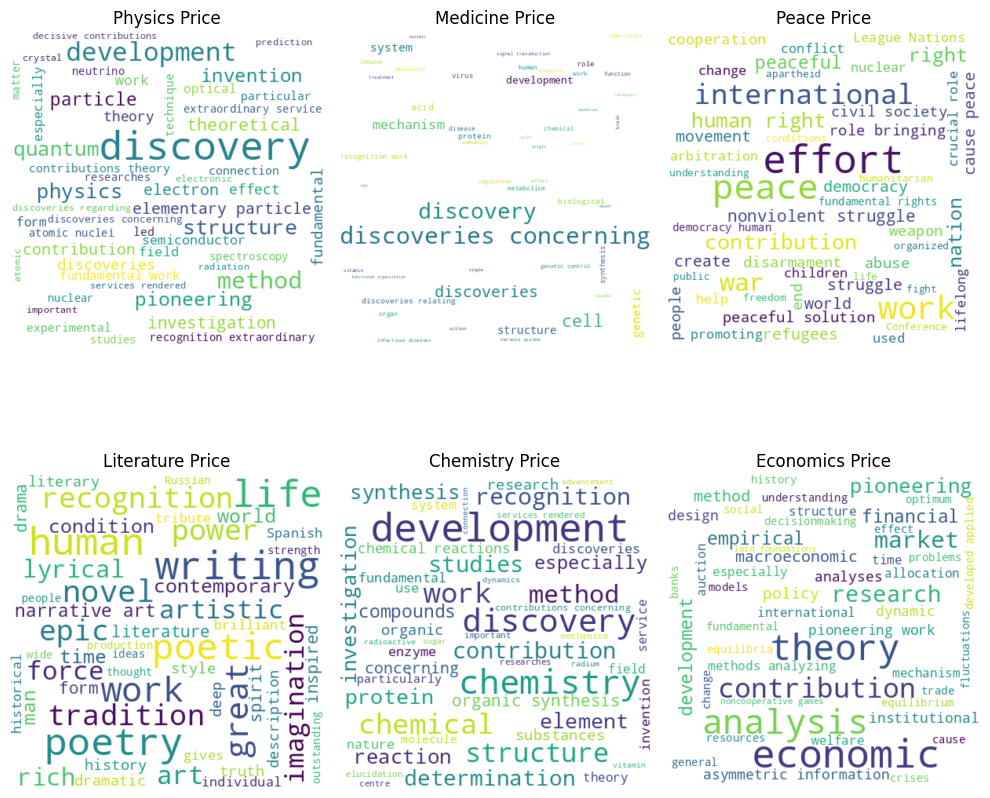

In [161]:
# NOTA: Este lo hice igual que en la practica 4, ahi aprendi hacerla asi para poder verlas todas juntas
textos = [words_physics, words_medicine, words_peace, words_literature,words_chemistry,words_economics]
titulos = ["Physics Price", "Medicine Price", "Peace Price", "Literature Price","Chemistry Price","Economics Price"]

fig, axes = plt.subplots(2, 3, figsize=(10, 10))
axes = axes.flatten()

for i, (texto, titulo) in enumerate(zip(textos, titulos)):
    wordcloud = WordCloud(
        max_font_size=50,
        width=400,
        height=400,
        max_words=50,
        background_color="white",
        colormap="viridis"
    ).generate(texto)

    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(titulo)

plt.tight_layout()
plt.show()

## Vectorizacion


In [162]:
from collections import Counter

In [143]:
def mostCommonWords (etiq):
  words = df_nobel[df_nobel.Etiqueta == etiq ].texto_completo.apply(lambda x : [word.lower() for word in x.split()])
  words_counter = Counter()

  for msg in words:
    words_counter.update(msg)

  return words_counter.most_common(10)


In [146]:
print(f"palabras comunes de physics {mostCommonWords(0)}")

palabras comunes de physics [('discovery', 97), ('development', 30), ('discoveries', 25), ('theory', 23), ('contributions', 22), ('fundamental', 21), ('work', 20), ('structure', 20), ('physics', 19), ('quantum', 19)]


In [147]:
print(f"palabras comunes de medicine {mostCommonWords(1)}")

palabras comunes de medicine [('discoveries', 130), ('concerning', 89), ('discovery', 72), ('system', 25), ('cell', 25), ('genetic', 22), ('cells', 18), ('work', 15), ('development', 14), ('structure', 13)]


In [148]:
print(f"palabras comunes de peace {mostCommonWords(2)}")

palabras comunes de peace [('peace', 48), ('efforts', 37), ('work', 33), ('international', 25), ('war', 24), ('rights', 22), ('peaceful', 16), ('nations', 15), ('struggle', 15), ('human', 15)]


In [149]:
print(f"palabras comunes de literature {mostCommonWords(3)}")

palabras comunes de literature [('poetry', 18), ('human', 18), ('life', 17), ('poetic', 16), ('art', 15), ('great', 12), ('narrative', 11), ('recognition', 10), ('writing', 10), ('epic', 10)]


In [150]:
print(f"palabras comunes de chemistry {mostCommonWords(4)}")

palabras comunes de chemistry [('development', 50), ('chemistry', 36), ('discovery', 32), ('chemical', 32), ('work', 28), ('synthesis', 23), ('structure', 20), ('studies', 20), ('organic', 18), ('contributions', 18)]


In [151]:
print(f"palabras comunes de economics {mostCommonWords(5)}")

palabras comunes de economics [('economic', 41), ('theory', 39), ('analysis', 35), ('contributions', 18), ('pioneering', 15), ('research', 13), ('markets', 10), ('development', 8), ('financial', 8), ('empirical', 8)]


In [240]:
nombre_archivo = 'novelCO.csv'
df_nobel.to_csv(nombre_archivo, index=False, encoding='utf-8')


# Examen Parte 3: Modelado Predictivo, Evaluación y Matriz de Confusión

## Separacion en conjunto de test y training

In [172]:
from sklearn.model_selection import train_test_split, cross_val_score

In [169]:
X = df_nobel.texto_completo
y = df_nobel.Etiqueta

print(X.shape)
print(y.shape)

(1007,)
(1007,)


In [170]:
print(X)
print(y)

0       recognition extraordinary services rendered di...
1       work serum therapy especially application diph...
2       humanitarian efforts help wounded soldiers cre...
3       lifelong work international peace conferences ...
4       special recognition poetic composition gives e...
5       recognition extraordinary services rendered di...
6       recognition extraordinary services rendered wo...
7       greatest living master art historical writing ...
8       eminently practical administration InterParlia...
9         untiring skilful directorship Bern Peace Bureau
10      recognition extraordinary service rendered res...
11      work malaria shown enters organism thereby lai...
12      recognition extraordinary service rendered res...
13      recognition extraordinary services rendered jo...
14      longstanding devoted effort favour ideas peace...
15      recognition extraordinary services rendered di...
16      recognition extraordinary services rendered jo...
17      recogn

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(704,)
(303,)
(704,)
(303,)


## CountVectorize

In [175]:
from sklearn.feature_extraction.text import CountVectorizer

In [176]:
vect = CountVectorizer()
vect.fit(X_train)

CountVectorizer()

In [178]:
X_train_dtm = vect.transform(X_train)
X_train_dtm = vect.fit_transform(X_train)

print(type(X_train_dtm), X_train_dtm.shape)

<class 'scipy.sparse._csr.csr_matrix'> (704, 1899)


In [179]:
X_test_dtm = vect.transform(X_test)
print(type(X_test_dtm), X_test_dtm.shape)

<class 'scipy.sparse._csr.csr_matrix'> (303, 1899)


In [180]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()
tfidf_transformer.fit(X_train_dtm)
tfidf_transformer.transform(X_train_dtm)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5381 stored elements and shape (704, 1899)>

## Naive Bayes


In [202]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn import metrics

nb = MultinomialNB()
nb.fit(X_train_dtm, y_train)

MultinomialNB()

In [203]:
y_pred_class = nb.predict(X_test_dtm)
print(f"Accuracy: {accuracy_score(y_test, y_pred_class)}")

Accuracy: 0.9108910891089109


Text(113.9222222222222, 0.5, 'Actual label')

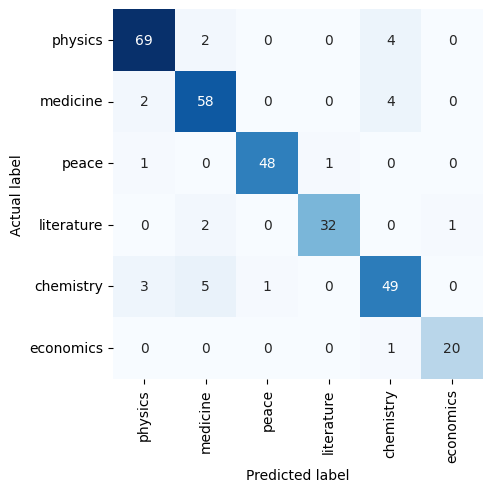

In [214]:
metrics.confusion_matrix(y_test, y_pred_class)
mat_NVS = metrics.confusion_matrix(y_test, y_pred_class)


labels = ['physics', 'medicine', 'peace', 'literature', 'chemistry', 'economics']
sns.heatmap(mat_NVS, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted label')
plt.ylabel('Actual label')

## Random Forest


In [232]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=14,
    random_state=42
)

In [233]:
# 4. Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train_dtm, y_train)

# 5. Realizar predicciones con los datos de prueba
y_pred = rf_model.predict(X_test_dtm)

In [234]:
from sklearn import metrics
preds_rf = rf_model.predict(X_test_dtm)
print(f"Accuracy: {accuracy_score(y_test, preds_rf)}")

Accuracy: 0.7524752475247525


Text(113.9222222222222, 0.5, 'Actual label')

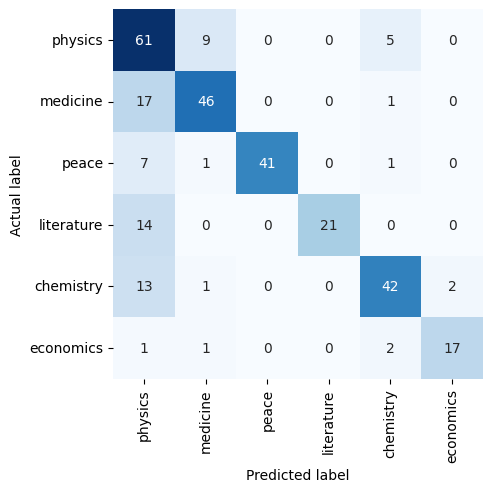

In [235]:
metrics.confusion_matrix(y_test, preds_rf)
mat_RF = metrics.confusion_matrix(y_test, preds_rf)


labels = ['physics', 'medicine', 'peace', 'literature', 'chemistry', 'economics']

sns.heatmap(mat_RF, square=True, annot=True, fmt='d', cbar=False, cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted label')
plt.ylabel('Actual label')

# Examen Parte 4: Streamlit

## Codigo StreamLit


In [242]:
%%writefile nobelstreamlit.py
import numpy as np
import streamlit as st
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


st.write(''' # Predicción de categoría de Premio Nobel ''')
st.image("Nobel.png", caption="Su creador fue el inventor sueco Alfred Nobel mediante su testamento en 1895.")

st.header('Texto')

def user_input_features():
  # Entrada
  texto = st.text_input("Introduce el texto a evaluar")

  user_input_data = {'Text': texto}

  features = pd.DataFrame(user_input_data, index=[0])

  return features

df = user_input_features()

nobel =  pd.read_csv('NobelCO.csv', encoding='latin-1')
X = nobel.texto_completo
y = nobel.Etiqueta

vect = CountVectorizer()
X_dtm = vect.fit_transform(X)

nb = MultinomialNB()
nb.fit(X_dtm, y)

df_dtm = vect.transform(df['Text'])
prediction = nb.predict(df_dtm)

#{'physics':0, 'medicine':1, 'peace':2, 'literature':3, 'chemistry':4, 'economics':5}
#'Physics', 'Medicine', 'Peace', 'Literature', 'Chemistry', 'Economics'
st.subheader('Predicción')
if prediction == 0:
  st.write('Physics')
elif prediction == 1:
  st.write('Medicine')
elif prediction == 2:
  st.write('Peace')
elif prediction == 3:
  st.write('Literature')
elif prediction == 4:
  st.write('Chemistry')
elif prediction == 5:
  st.write('Economics')
else:
  st.write('Sin predicción')


Writing nobelstreamlit.py


## LINK STREAMLIT: https://examen-jmca.streamlit.app/

# Examen Parte 5 : Dashboard Power BI


RAW Data para el dashboard: `https://raw.githubusercontent.com/JoseColins1OO/ExamenModulo4/refs/heads/main/NobelLimpio.csv`

## link dashbo : `https://app.powerbi.com/groups/me/reports/f6f7661e-c61a-4ef5-8825-d39aadbf2d69/323b80c7eaead5270734?experience=power-bi`